# 인터랙티브 플롯(Interactive Plot)

지금까지 우리가 다룬 플롯은 단순히 눈으로만 보는 정적인 그림이었는데요,

인터랙티브 플롯은 눈으로 보는걸 넘어서 마우스/키보드로 직접 조작하며 데이터를 탐색할 수 있는 플롯을 의미합니다.

예를 들어 함수 $f(x) = ax^2+b+c$는 $a,b,c$의 값에 따라 모양이 결정되는데요, 

지금까지 우리는 $a,b,c$를 플롯을 코딩하는 단계에서 미리 정하고, 그 정해진 값에 대해서 함수를 그려봤었습니다.

인터랙티브 플롯은 $a,b,c$를 코딩 단계가 아닌, 플롯이 완성된 단계에서 조절해가면서 모양을 실시간으로 확인할 수 있는 그런 플롯이에요.

인터랙티브 플롯을 사용하려면 모둘 `ipywidgets`가 필요합니다.


## 설치

모둘 `ipywidgets`은 파이썬의 표준 라이브러리에 들어있지 않아서요, 경우에 따라서 설치가 필요할 수 있습니다.

이를 위한 명령어는 다음과 같습니다.

```bash
%pip install ipywidgets
```

## 인터랙티브 플롯을 위한 기본 세팅

기본 세팅은 다음과 같습니다.

```python
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
```

In [1]:
# 참고로 주피터 말고 일반 파이썬 환경이시라면 pip install ipywidgets를 터미널에 입력하세요.

%pip install ipywidgets 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets

NumPy는 거의 대부분의 경우 필수이구요, 당연히 플롯하니까 `matplotlib`도 필요하고,

`ipywidgets`도 임포트가 필요할테고, 그 중에서도 우리는 인터랙티브 플롯을 그릴거니 `interact`라는 함수를 임포트해줍니다.


이 세팅이 끝났다면 우리는 인터랙티브 플롯을 사용할 대상을 그리는 함수를 정의해야합니다.

이 함수는 인터랙티브 플롯의 토대로, 우리는 파라미터로 인터랙티브 플롯에서 변경할 수 있는 친구를 넣습니다.

백문이 불여일견이라고 그냥 바로 예시를 보시죠.

In [3]:
# 우리는 sin(ax)를 그릴 예정입니다. frequency는 a로, 이 a를 변경할 수 있도록 구성됩니다.
# 설명한대로 변경의 대상이 되는 frequency가 함수의 파라미터로 들어갑니다.
def plot_sine_wave(frequency):
    x = np.linspace(0, 2*np.pi, 100) # [0,2pi]에서만 생각하기 위해 이 구간을 linspace로 쪼갭니다.
    y = np.sin(frequency * x) # 함수값
    # 그리고 이대로 플롯합니다.
    plt.plot(x, y)
    plt.show()
# plot_sine_wave는 여기서 정의가 끝납니다.
# 이 상태에서 plot_sine_wave는 인터랙티브 플롯으로 불러올 준비를 모두 마쳤습니다.

# 인터랙티브 플롯은 위에서 임포트해온 interact()함수를 사용하여 생성합니다 :

interact(plot_sine_wave, frequency = 1)# 플롯의 함수를 전달하고, 조작할 frequency의 디폴트 값을 설정
None

interactive(children=(IntSlider(value=1, description='frequency', max=3, min=-1), Output()), _dom_classes=('wi…

위 코드를 실행하면 위에 `frequency`를 조절할 수 있는 바가 나오는데요, 

`plot_sine_wave()`의 구성에 따라 우리의 함수는 $\sin(ax)$의 꼴이고, `frequency`는 $a$에 해당되므로,

저 바로 `frequency`의 값을 조절하면서 우리는 함수의 모양이 달라지는걸 확인할 수 있습니다.

또 마지막 줄에 `None`이 오는데요, 이건 주피터 노트북이라서 사용하는 명령어입니다.

딱히 특별한 역할은 아니구요, 주피터 노트북은 마지막의 표현을 계산해서 반환하는데, 이 반환 기능을 끄는거에요.

이제 인터랙티브 플롯이 뭔지는 이해가 다 되셨을테니, 본격적으로 저 코드에 등장하는 친구들을 좀 더 살펴볼게요.

## 함수 `interact()`

함수 `interact()`는 사용자와 상호작용하는, 인터랙티브한 대상을 생성하기 위해 사용됩니다.

이 함수는 다음과 같은 파라미터들을 받습니다.

```python
interact(func, **kwargs)
```

간단합니다. 위에서 보셨다시피 우선 해당 함수는 우리가 플롯을 그릴 대상이 돠는 함수가 들어가구요,

그 다음으로는 우리가 상호작용으로 바꾸는걸 허용할 변수들이 들어옵니다.

위에서 우리는 다음의 명령어를 사용했엇죠.

```python
interact(plot_sine_wave, frequency=1)    
None
```

그러면 `interact`는 `plot_sine_wave`에 대해, 상호 작용 시 가변인 친구는 `frequency`이고, 이 놈의 초기값을 1로 잡습니다.

그리고 자동으로 `-1`부터 `3`까지의 범위를 움직일 수 있도록 조정합니다.

이렇게 초기값만 `x`만 알려주는 경우에는 자동으로 `[-x,3*x]`의 범위에서 해당 변수를 움직일 수 있도록 동작합니다.

당연히 굳이 초기값 뿐 아니라, 변수를 바꿀 수 있는 범위 자체를 정할 수도 있습니다 :

In [4]:
interact(plot_sine_wave, frequency=(0,10,1))    
None

interactive(children=(IntSlider(value=5, description='frequency', max=10), Output()), _dom_classes=('widget-in…

위와 같이 `frequency = (0,10,1)`을 한다면, 0부터 10까지, 1의 간격으로 `frequency`를 바꿀 수 있게 됩니다. `(start, end, step)`의 순서에요.

그런데 생성된 플롯을 보시면, `frequency`를 바꿀 수 있는 직관적인 바가 하나 있는데요, 이런 친구들을 위젯이라고 합니다.

기본적으로는 따로 특별한 명령이 없다면 (수치적인 변수에 대해서는) 저런 형태의 슬라이드 위젯이 생성되는데요,

당연히 위젯에도 다양한 종류가 있습니다. 얘네들도 `ipywidgets`의 객체의 일종이에요.

## 위젯의 종류들

위젯은 다음과 같은 종류들이 있습니다.

- `FloatSlider` : 변수를 슬라이드 형태로 float 범위에서 변경 가능
- `IntSlider`: 변수를 슬라이드 형태로 int 범위에서 변경 가능
- `Dropdown`: 드롭다운 메뉴
- `RadioButtons`: 라디오 버튼들의 그룹
- `Checkbox`: 체크박스
- `Text`: 그냥 텍스트
- 기타 등등


이번 포스팅에서는 위 리스트의 위에서부터 5개의 위젯들만을 다룹니다.

위에서 만들어본 인터랙티브 플롯에는

```python
interact(plot_sine_wave, frequency=(0,10,1)) 
```

이렇게 `frequency`에 값의 범위만을 지정해줬었는데요, 위젯을 지정하는 경우에는 `frequency`에 이 위젯 객체를 생성해서 넣습니다.

지금은 저 위젯의 종류들을 보시더라도 슬라이더를 제외하면 뭔지 감이 잘 안오실텐데요, 각각 하나씩 자세히 살펴보도록 하겠습니다.


### 슬라이더(Slider)

슬라이더는 위에서도 본대로, 매우 직관적으로 바에서 버튼을 움직여서 값을 조절하는 위젯입니다.

`FloatSlider`와 `IntSlider`는 슬라이드에서 고를 수 있는 수치가 부동소수형인지 정수형인지에만 차이가 있고, 그 외에는 같습니다.

이 둘은 생성 시 다음의 속성들을 받습니다 :

- `value`: 초기값(플롯 시 바로 처음에 그려질 플롯에 사용할 변수의 초기값)
- `min`: 상호작용 시 값을 변경할 수 있는 최소 하한
- `max`: 최대 하한
- `step`: 보폭(슬라이더를 한 칸 움직일 시 어느 값의 보폭으로 값이 변경되는지)
- `description`: 변수의 이름을 수정(만약 입력되지 않는 경우, 기존의 변수 이름을 그대로 사용)

예를 들어 다음의 친구를 생성할 수 있습니다.

In [5]:
interact(plot_sine_wave, 
         frequency = widgets.FloatSlider(
             value = 0,
             min = -5,
             max = 5,
             step = 0.5,
             description = '변수 이름')) # description을 안적으면 기존의 변수 이름인 frequency가 그대로 들어갑니다.    
None

interactive(children=(FloatSlider(value=0.0, description='변수 이름', max=5.0, min=-5.0, step=0.5), Output()), _do…

그 외에도 위젯의 생성자에는 `layout`이라는 파라미터를 전달할 수 있는데요,

```python
layout = widgets.Layout(width = '500px') 
```

예를 들어 위와 같은 친구를 `FloatSlider()`함수 안에 넣으면, 우리의 슬라이더 위젯의 너비(바의 너비)를 500 픽셀로 지정할 수 있습니다.

Layout에는 다음과 같은 속성을 전달하여 위젯의 모양을 지정해줄 수 있습니다.

- `width`, `height` 너비와 높이
- `margin` 위젯 밖의 여백
- `padding` 위젯 안의 여백
- `border` 위젯 테두리 스타일
- `display` 배치 방식
- `justify_content` 가로 정렬
  
이 친구들에 각각 어떤 선택지들이 있는지는 `list(widgets.Layout().keys)` 등으로 확인하실 수 있습니다.

여튼 슬라이더를 생성할 시 해당 속성들은 저렇게 5개를 각각 적어줘도 되지만, 좀 더 짧게 줄여서도 가능합니다.

### 다중 위젯

위젯은 플롯에 무조건 하나만 넣어야하는건 아닙니다. 여러 변수를 변경하고 싶으면, 여러 개를 할 수 있겠죠.

그 방법도 간단해요. 똑같이 `interact()`함수에 여러 변수를 넣어주면 됩니다.

물론 이 때는 기존에 정의했던 플롯 함수도 그 변수들의 개수에 맞는 입력 변수를 받을 수 있도록 수정해야합니다.

예를 들어 함수 $y = a\sin(bx)$는 다음의 형태로 구현할 수 있습니다.

In [6]:
def plot_sine(frequency, amplitude):
    x = np.linspace(0, 10, 100)
    y = amplitude * np.sin(frequency * x)
    plt.plot(x, y)
    plt.show()
interact(plot_sine, frequency=(1, 10,0.1), amplitude=(1, 10, 0.1))
None

interactive(children=(FloatSlider(value=5.0, description='frequency', max=10.0, min=1.0), FloatSlider(value=5.…

위 플롯에서 값을 변경하시면 `frequency`가 변경될 때마다 그래프가 새로 그려지고, `amplitude`를 변경할 때 마다 축이 새로 그려지는걸 알 수 있습니다.

이런 인터랙티브 플롯의 기본적인 원리는 `interact()`가 내부적으로 계속 사용자가 변경한 값에 맞게 플롯을 그리는 함수를 계속 호출해서, 

그걸 토대로 실시간으로 함수의 모양을 변형시켜 보여주는겁니다.

### 선택 위젯

`Dropdown`, `RadioButtons`, `Checkbox` 위젯들은 선택을 하는 기능을 구현하는 위젯입니다.

위에서 슬라이더는 바의 슬라이드를 움직여서 값을 변경했다면, 이 친구들은 주어진 칸에서 값을 선택하는 형태의 위젯인거죠.

저 세 놈은 모두 같은 용도로 그 모양을 어떻게 구현할지에 따른 차이 정도만 있습니다.

따라서 구성되는 속성들도 똑같고, 이는 다음과 같습니다 :

- `options`: 선택지들을 모은 리스트
- `value`: 가장 처음 보여줄 초기값
- `description`: 변수들의 이름

간단합니다. 그냥 똑같은데 방식만 다른거라 따로 설명할만한거도 없네요. 사용법도 완전 같아요.

물론 다른 속성들도 존재하는데, 굳이 다루지 않고 넘어가겠습니다. 필요하다면 Doc를 참고하시면 될거에요.

`Dropdown`, `RadioButtons`, `Checkbox`는 아래에서 더 예시와 함께 자세히 다뤄집니다.

슬라이더 위젯은 단순히 변수나 상수의 값을 변경했을 때 플롯이 어떻게 변화하는지를 살펴보기에 매우 적합합니다.

그에 비해서 선택 위젯의 경우, 우리가 이산적으로 변경할 수 있는 값, 예를 들어서 그리는 함수의 종류를 몇 개 한정지어놓고,

그걸 선택하여 인터랙티브 플롯으로 실시간으로 플롯의 모양의 변화를 확인하는 등의 방법으로 활용할 때 요긴하죠.


위에서는 사인 함수를 고정하여 그렸었는데, 이제는 사인 뿐 아니라 여러 함수를 고를 수 있도록 인터랙티브 플롯을 그려보겠습니다.

In [7]:
# 이번에도 interact() 안에 넣을 함수를 정의하고, 함수의 파라미터로는 변경의 대상이 되는 함수 이름을 집어넣습니다.
def plot_trig_function(function_name):
    x = np.linspace(-2*np.pi, 2*np.pi, 1001) # 플롯할 구간
    if function_name == 'Cos': # 코사인
        y = np.cos(x)
        plt.ylim(-1, 1)
    elif function_name == 'Sin' : # 사인
        y = np.sin(x)
        plt.ylim(-1, 1)
    else :
        y = np.tan(x) #탄젠트
        plt.ylim(-3, 3) # 탄젠트는 함수 값이 1을 넘어가니까 일부러 탄젠트만 이렇게 설정해줍니다.
    
    plt.plot(x, y)
    plt.plot(x,np.zeros((len(x),)), 'k-')
    plt.title(function_name)
    plt.xlim(-2*np.pi, 2*np.pi)
    plt.xticks([-2*np.pi, -1*np.pi,0, np.pi, 2*np.pi], [r'$-2\pi$', r'$-\pi$', '0',r'$\pi$', r'$2\pi$'])
    plt.show()

dropdown_widget = widgets.Dropdown( # widgets.Dropdown의 형태로 선택 위젯을 정의했습니다.
    options=['Sin', 'Cos','Tan'],   # 설명한대로 우선 선택지의 리스트,
    value='Sin',                    # 초기값(디폴트)
    description='그릴 함수'          # 이 위젯으로 뭘 바꾸는건지에 대한 설명을 넣어줍니다.
)

interact(plot_trig_function, function_name=dropdown_widget)
None

interactive(children=(Dropdown(description='그릴 함수', options=('Sin', 'Cos', 'Tan'), value='Sin'), Output()), _d…

그러면 위와 같이 대표적인 3가지의 삼각 함수를 선택하여 그릴 수 있는 인터랙티브 플롯이 생성됩니다.

`Dropdown`은 보시다시피 누르면 아래로 펼쳐져서, 함수를 고를 수 있는 형태의 선택 박스입니다.

그리고 `RadioButtons`는 다음과 같은 형태가 됩니다.

In [8]:
# 이번에도 interact() 안에 넣을 함수를 정의하고, 함수의 파라미터로는 변경의 대상이 되는 함수 이름을 집어넣습니다.
def plot_trig_function(function_name):
    x = np.linspace(-2*np.pi, 2*np.pi, 1001) # 플롯할 구간
    if function_name == 'Cos': # 코사인
        y = np.cos(x)
        plt.ylim(-1, 1)
    elif function_name == 'Sin' : # 사인
        y = np.sin(x)
        plt.ylim(-1, 1)
    else :
        y = np.tan(x) #탄젠트
        plt.ylim(-3, 3) # 탄젠트는 함수 값이 1을 넘어가니까 일부러 탄젠트만 이렇게 설정해줍니다.
    
    plt.plot(x, y)
    plt.plot(x,np.zeros((len(x),)), 'k-')
    plt.title(function_name)
    plt.xlim(-2*np.pi, 2*np.pi)
    plt.xticks([-2*np.pi, -1*np.pi,0, np.pi, 2*np.pi], [r'$-2\pi$', r'$-\pi$', '0',r'$\pi$', r'$2\pi$'])
    plt.show()

radio = widgets.RadioButtons( # widgets.Dropdown의 형태로 선택 위젯을 정의했습니다.
    options=['Sin', 'Cos','Tan'],   # 설명한대로 우선 선택지의 리스트,
    value='Sin',                    # 초기값(디폴트)
    description='그릴 함수'          # 이 위젯으로 뭘 바꾸는건지에 대한 설명을 넣어줍니다.
)

interact(plot_trig_function, function_name=radio)
None

interactive(children=(RadioButtons(description='그릴 함수', options=('Sin', 'Cos', 'Tan'), value='Sin'), Output())…

마지막으로 `Checkbox`는 좀 특이한데요, 위의 두 친구는 한 번에 하나의 함수만 플롯 가능했으나,

체크박스는 말 그대로 체크박스 형태로 선택지가 주어져서, 그거를 동시에도 활성화할 수 있는 기능이 있습니다.

이 때는 지금까지 다룬 다른 위젯들과는 다르게, 이 선택지들이 모두 서로 다른 체크박스 위젯이 되어야 합니다.

위의 삼각 함수 예시 기준으로 설명하면, `sin`, `cos`, `tan`이라는 선택지가 있고, 이 안에서 또 각각의 함수들을 `on/off` 선택지가 주어져야한다는거죠.

따라서 `interact()`에 절달되는 함수 `plot_trig_functions()`도 이번엔 매개변수를 이 선택지의 개수만큼 만들어줘야합니다.

그리고 `plot_trig_functions()`를 정의하는 시점에서부터 `figure`가 필요하게 됩니다.

In [9]:
def plot_trig_function(sin,cos,tan): # sin, cos, tan은 이제 True/False의 부울 표현으로 생각해야합니다. True면 그 함수 플롯을 키고, False면 끈다는 느낌
    
    x = np.linspace(-2*np.pi, 2*np.pi, 1001) # 플롯할 구간
    fig = plt.figure()
    
    if cos : # 코사인이 True인 경우, 다음과 같이 플롯합니다.
        plt.plot(x,np.cos(x), label = r'$\cos$')
        
    if sin : # 사인이 True인 경우에도 마찬가지로 사인을 플롯
        plt.plot(x,np.sin(x), label = r'$\sin$')
        
    if tan : # 탄젠트도 마찬가지
        plt.plot(x,np.tan(x),label = r'$\tan$')

    # 플롯 형태 꾸미기

    if cos or sin or tan : 
        plt.legend()
    plt.ylim(-1, 1)
    plt.plot(x,np.zeros((len(x),)), 'k-')
    plt.title('Trigonometric Functions')
    plt.xlim(-2*np.pi, 2*np.pi)
    plt.xticks([-2*np.pi, -1*np.pi,0, np.pi, 2*np.pi], [r'$-2\pi$', r'$-\pi$', '0',r'$\pi$', r'$2\pi$'])
    plt.show()


checkbox_cos = widgets.Checkbox(value=False, description='cos(x)') # 기본값은 False로, 아무거도 안그리는 형태로 둡니다. 
checkbox_sin = widgets.Checkbox(value=False, description='sin(x)')
checkbox_tan = widgets.Checkbox(value=False, description='tan(x)')


interact(plot_trig_function, cos = checkbox_cos, sin=checkbox_sin, tan = checkbox_tan)
None

interactive(children=(Checkbox(value=False, description='sin(x)'), Checkbox(value=False, description='cos(x)')…

그러면 우리는 위와 같이 선택지를 동시에 누를 수 있는 형태의 인터랙티브 플롯을 만들어낼 수 있습니다.

참고로 `plot_trig_function(sin, cos, tan)`의 내부를 보시면 조건문들이 

```python
    if cos : # 코사인이 True인 경우, 다음과 같이 플롯합니다.
        plt.plot(x,np.cos(x), label = r'$\cos$')
        
    if sin : # 사인이 True인 경우에도 마찬가지로 사인을 플롯
        plt.plot(x,np.sin(x), label = r'$\sin$')
        
    if tan : # 탄젠트도 마찬가지
        plt.plot(x,np.tan(x),label = r'$\tan$')
```

이렇게, 기존의 `if-elif-else`의 구조에서 변화했는데요, 이는 동시에 체크가 가능하다는 상황이기 떄문입니다.

기존에는 하나의 체크만 가능하다는 전제라서 `if-elif-else`를 해도 괜찮았으나, 이제 동시에 가능하기 떄문에

위와 같이 전부 `if`를 각각 사용하셔야합니다.

## 위젯 합체하기

정리하자면 슬라이더는 수치를 바꿀 때, 선택 위젯은 함수를 바꿀 때와 같은 경우에 사용하면 참 좋은데요,

당연히 우리는 이를 합쳐서, 수치도 바꾸고 함수도 바꿀 수 있는 인터랙티브 플롯을 그릴 수 있습니다.

위에서 했던 모든 과정을 다 합쳐볼게요. 우리는 실수 $a,b$, 그리고 함수 $fun c\in \{\cos,\sin,\tan\}$에 대해서 다음 형태의 함수를 인터랙티브 플롯하곘습니다.

$$
a\cdot func(bx),\quad x \in [-2\pi, 2\pi]
$$


그니까 함수도 선택할 수 있고, `a,b`, 즉 기존의 `amplitude`와 `frequency`도 바꿀 수 있는 플롯을 그리는거에요. 방법은 똑같습니다.

In [10]:
import ipywidgets as widgets
from ipywidgets import interact, HBox, VBox
import numpy as np
import matplotlib.pyplot as plt

def plot_trig_functions(cos,sin,tan, cos_freq, cos_amp, sin_freq, sin_amp, tan_freq, tan_amp):
    x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)
    plt.figure()

    # 이번에도 동시에 선택이 가능한 Checkbox를 사용합니다. 따라서 if 3개!
    if cos :
        plt.plot(x, cos_amp * np.cos(cos_freq * x), label='cos') # 물론 함수를 그릴 떄에는 a*cos(bx)의 형태가 되도록 해야합니다.
        
    if sin:
        plt.plot(x, sin_amp * np.sin(sin_freq * x), label='sin')

    if tan :
        plt.plot(x, tan_amp* np.tan(tan_freq * x), label ='tan')
    
    if cos or sin or tan :
        plt.legend()

    plt.title('Trigonometric Functions')
    plt.xlim(-2 * np.pi, 2 * np.pi)
    plt.ylim(-5, 5)

    plt.show()


# 각 체크박스 및 슬라이더를 정의합니다.
checkbox_cos = widgets.Checkbox(value=False, description='cos(x)', layout=widgets.Layout(width='200px'))
checkbox_sin = widgets.Checkbox(value=False, description='sin(x)', layout=widgets.Layout(width='200px'))
checkbox_tan = widgets.Checkbox(value=False, description='tan(x)', layout=widgets.Layout(width='200px'))

cos_freq_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.01, description='Freq.', layout=widgets.Layout(width='240px'))
cos_amp_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.01, description='Amp.', layout=widgets.Layout(width='240px'))
sin_freq_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.01, description='Freq.', layout=widgets.Layout(width='240px'))
sin_amp_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.01, description='Amp.', layout=widgets.Layout(width='240px'))
tan_freq_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.01, description='Freq.', layout=widgets.Layout(width='240px'))
tan_amp_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.01, description='Amp.', layout=widgets.Layout(width='240px'))


# 함수별로 위젯을 묶어서 보기 편하게 만드는 단계입니다. VBox는 수직으로 쌓는거, HBox는 수평으로 나열하는겁니다.
left_box = VBox([checkbox_cos, cos_freq_slider, cos_amp_slider])
mid_box = VBox([checkbox_sin, sin_freq_slider, sin_amp_slider])
right_box = VBox([checkbox_tan, tan_freq_slider, tan_amp_slider])

# 이 시점에서 Vbox로 인해서 cos/sin/tan의 체크박스와 슬라이더 둘은 세로로 쌓입니다. 총 3개의 세로 박스가 생성됩니다.

# 그리고 아래와 같이 HBox로 세 박스를 묶어서, 수평으로 나열합니다. 모양은 보시면 직관적으로 이해되실겁니다.
ui = HBox([left_box, mid_box , right_box])

# 이번에는 interact() 대신, interactive_output()이라는 함수를 사용합니다. 그 이유는 위에서 박스를 만드는거처럼 우리가 수동으로 모양을 지정하기 떄문
out = widgets.interactive_output(plot_trig_functions, {'cos': checkbox_cos,
                                                       'sin': checkbox_sin,
                                                       'tan': checkbox_tan,
                                                       'cos_freq': cos_freq_slider,
                                                       'cos_amp': cos_amp_slider,
                                                       'sin_freq': sin_freq_slider,
                                                       'sin_amp': sin_amp_slider,
                                                       'tan_freq': tan_freq_slider,
                                                       'tan_amp': tan_amp_slider
                                                      })
# ui와 out에 저장된 interactive_output의 결과물을 합쳐서 디스플레이하기! 이건 주피터 노트북의 기능입니다.
display(ui, out)

Output()

위 코드는 전보다는 좀 더 복잡해보일 수 있는데 간단합니다.

결국 주석을 따라가시면 이해는 모두 되실텐데요, 아래 부분이 좀 생소하실거에요.

```python
left_box = VBox([checkbox_cos, cos_freq_slider, cos_amp_slider])
mid_box = VBox([checkbox_sin, sin_freq_slider, sin_amp_slider])
right_box = VBox([checkbox_tan, tan_freq_slider, tan_amp_slider])

ui = HBox([left_box, mid_box , right_box])

out = widgets.interactive_output(plot_trig_functions, {'cos': checkbox_cos,
                                                       'sin': checkbox_sin,
                                                       'tan': checkbox_tan,
                                                       'cos_freq': cos_freq_slider,
                                                       'cos_amp': cos_amp_slider,
                                                       'sin_freq': sin_freq_slider,
                                                       'sin_amp': sin_amp_slider,
                                                       'tan_freq': tan_freq_slider,
                                                       'tan_amp': tan_amp_slider
                                                      })
display(ui, out)
```

이 부분은 결국 그냥 인터랙티브 플롯을 이쁘게 만드는 과정일 뿐입니다.

우리는 플롯을 좀 더 보기 좋게 만들기 위해 해당 코드의 가장 처음에서 `left_box, mid_box, right_box`로 각 함수 $\cos,\sin,\tan$별로 

각 함수들에 대한 체크박스와 슬라이더를 `VBox`로, 즉 박스안에 세로로 각 위젯을 쌓아올리는 형태로 같이 모읍니다.

그리고 나서 `ui`라는 친구 안에 `HBox`로 `VBox`를 나란히 가로로 3개 묶은 친구를 저장합니다.

이름이 `ui`인건 우연이 아니라, 진짜 User-Interface의 역할을 하는 친구이기 떄문입니다. 사용자가 직접 플롯과 상호작용할 부분이 여기 다 들어있죠.

그리고 `out`에는 `widgets.interactive_output()`이라는 함수를 이용하여 `plot_trig_functions`와 각 체크박스 및 슬라이더를 연결해줍니다.

이번에는 위젯이 너무 많아서, 위와 같이 딕셔너리 형태로 전달해줍니다. `interact()`에서도 딕셔너리를 전달할 수 있는데, 이 떄는 딕셔너리 앞에 `**`를 붙여줍니다.

근데 왜 `interact()` 대신에 `interactive_output()`을 사용할까요?

그 이유는 간단합니다. `interact()`는 사용자 대신에 많은걸 알아서 해주는 함수입니다.

기존의 `interact()`함수는 위젯의 디테일한 위치 설정 등도 전부 자기 알아서 하는데요,

문제는 이 자기 알아서가 당연히 꽤나 대충 그냥 순서대로 자동으로 저 위젯들을 나열할 뿐이라, 저렇게 선택지가 많은 경우에는 난잡하다는거죠.

그래서 `interactive_output()`이라는 `interact()`보다는 좀 더 사용자에게 노동을 요구하나, 더 결과물은 깔끔하게 만들 수 있는 친구를 사용하는거에요.

그런데 `interact()`는 그 외에도 자동으로 인터랙티브 플롯을 생성하여 보여주는 기능도 있는데, `interactive_output()`은 그런 기능이 없습니다.

딱 `out`에는 `plot_trig_functions`와 우리가 정의한 위젯들이 연결되어있다는 정보까지만 저장되어 있습니다.

따라서 이걸 `ui`에서 정의한 형태로 출력하기 위해서 주피터 노트북 환경에서는 `display(ui, out)`으로 둘을 명시적으로 출력해줘야합니다.

근데 여기서 주의할 점이 있어요. `ui`는 진짜 말 그대로, 그냥 겉에서 보는 껍데기일 뿐이고, 진짜 변화하여 플롯을 하는 친구는 `out`입니다.

그럼에도 `ui`와 `out`은 위에서도 보시다시피 같은 위젯을 가리키기 떄문에, `ui`의 변화에 따라서 `out`도 그 변화를 알아차리는거에요.



만약 그냥 기존의 방식대로 바로 `interact()`를 사용하면 아래와 같은 플롯이 생성됩니다.

In [11]:
import ipywidgets as widgets
from ipywidgets import interact, HBox, VBox
import numpy as np
import matplotlib.pyplot as plt

def plot_trig_functions(cos,sin,tan, cos_freq, cos_amp, sin_freq, sin_amp, tan_freq, tan_amp):
    x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)
    plt.figure()

    # 이번에도 동시에 선택이 가능한 Checkbox를 사용합니다. 따라서 if 3개!
    if cos :
        plt.plot(x, cos_amp * np.cos(cos_freq * x), label='cos') # 물론 함수를 그릴 떄에는 a*cos(bx)의 형태가 되도록 해야합니다.
        
    if sin:
        plt.plot(x, sin_amp * np.sin(sin_freq * x), label='sin')

    if tan :
        plt.plot(x, tan_amp* np.tan(tan_freq * x), label ='tan')
    
    if cos or sin or tan :
        plt.legend()

    plt.title('Trigonometric Functions')
    plt.xlim(-2 * np.pi, 2 * np.pi)
    plt.ylim(-5, 5)

    plt.show()


# 각 체크박스 및 슬라이더를 정의합니다.
checkbox_cos = widgets.Checkbox(value=False, description='cos(x)', layout=widgets.Layout(width='200px'))
checkbox_sin = widgets.Checkbox(value=False, description='sin(x)', layout=widgets.Layout(width='200px'))
checkbox_tan = widgets.Checkbox(value=False, description='tan(x)', layout=widgets.Layout(width='200px'))

cos_freq_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.01, description='CosFreq.', layout=widgets.Layout(width='240px'))
cos_amp_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.01, description='CosAmp.', layout=widgets.Layout(width='240px'))
sin_freq_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.01, description='SinFreq.', layout=widgets.Layout(width='240px'))
sin_amp_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.01, description='SinAmp.', layout=widgets.Layout(width='240px'))
tan_freq_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.01, description='TanFreq.', layout=widgets.Layout(width='240px'))
tan_amp_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.01, description='TanAmp.', layout=widgets.Layout(width='240px'))

# 위젯 객체들은 그대로 사용합니다.

interact(plot_trig_functions, 
         cos=checkbox_cos, 
         sin=checkbox_sin, 
         tan=checkbox_tan,
         cos_freq=cos_freq_slider, 
         cos_amp=cos_amp_slider,
         sin_freq=sin_freq_slider, 
         sin_amp=sin_amp_slider,
         tan_freq=tan_freq_slider, 
         tan_amp=tan_amp_slider)
None

interactive(children=(Checkbox(value=False, description='cos(x)', layout=Layout(width='200px')), Checkbox(valu…

딱 봐도 위에서 `interactive_output()`을 사용하는 게 더 보기 좋죠 ㅋㅋ

물론 플롯 그 자체는 상관이 없는데, 확실히 유저가 사용하기에는 저렇게 UI를 하나 구성해주는 게 훨씬 좋습니다.

## 3D 플롯

당연히 3D 플롯도 인터랙티브하게 만들 수 있습니다. 2D랑 똑같아요.

예시로 이번에는 원뿔을 이산화하여 그리는 방법의 일종으로, 밑면은 $n$각형으로한 $n$각뿔을 그려보도록하겠습니다.

이 때, $n$을 변하게 할 수 있도록 설정하여 모양이 $n$에 따라서 얼마나 더 원뿔에 가까운 형태가 되는지를 직관적으로 볼 수 있도록 하는거죠.

방법은 그냥 사실상 똑같습니다.

In [12]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_npyramid(ax,h,n):
    '''
    ax : 플롯이 저장될 Axes 객체
    h : n각뿔의 높이
    n : n
    '''
    
    top = [0,0,h] # n각뿔의 뾰족한 위쪽 꼭짓점

    t = np.linspace(0,2*np.pi,n+1 ) # 파라미터 t를 이용합니다.

    # x,y는 정 n각형 밑면의 각 꼭짓점을 표현하기 위한 좌표입니다.
    x = np.sin(t)
    y = np.cos(t)
    
    ax.plot(x,y,0, color ='red') # 좌표 (x,y)들을 모두 이어 n각형의 밑면을 그립니다.

    # 이제 주어진 정보를 이용하여 밑면을 Poly3DCollection 객체로 그려냅니다.
    ax.add_collection3d(Poly3DCollection([[[x[i],y[i],0] for i in range(n)]]  , alpha=0.2, color='green'))

    # 꼭짓점을 Scatter로 플롯합니다.
    ax.scatter(top[0],top[1],top[2])

    # 이제 밑면의 각 인접한 두 점과 꼭대기 top을 연결한 삼각형 다각형을 Poly3DCollection 객체로 만들어 우리의 ax에 더합니다.
    for j in range(n):
        ax.add_collection3d(Poly3DCollection([[[x[i],y[i],0] for i in [j,j+1] ]+[top] ]  , alpha=0.2, linewidths=1, edgecolors='black'))

# 이 시점에서 이미 plot_npyramid()로 n각형을 그릴 준비는 완료됩니다.

#이제 저걸 이용해서 interact()와 함께 인터랙티브 플롯을 그리는 함수(interact() 안에 넣을 친구)를 정의합니다 :

def plot_interact_npyramid(h, n): # plot_npyramid랑 h,n은 같습니다.
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    plot_npyramid(ax,h,n)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(0, 2)
    plt.show()

interact(plot_interact_npyramid, h=(0.1,2,0.1), n=(3,20,1))
None

interactive(children=(FloatSlider(value=1.0, description='h', max=2.0, min=0.1), IntSlider(value=11, descripti…

### 인터랙티브 플롯의 응용 : 관측 방향

우리는 3D 플롯의 전용 옵션으로 `view_init(elev,azim)`라는 함수를 통해서, 우리가 그 플롯을 어느 방향에서 관측할건지를 정할 수 있었습니다.

`elev`는 -90\~90도의 상하의 방향을 의미했으며, `elev`는 $xy$평면에서 방향각(0\~360)을 의미했었죠. 배그에서 그 30 방향 어쩌고 할 때 그거요.

인터랙티브 플롯을 활용하면 위에서 한거처럼 단순히 변수의 값들/함수를 바꿔가며 관측하는 플롯도 그릴 수 있지만,

더 나아가 같은 함수라도 이 `elev`와 `azim`을 인터랙티브하게 변경할 수 있는 변수로 두고, 관측하는 관점을 바꿀 수도 있습니다.

이 친구들은 모두 수치적인 파라미터이므로, `FloatSlider`를 사용할 수 있습니다. $z = y*\sin(x)$라는 함수를 그려볼게요 :

In [13]:
def plot_view(elevation, azimuth):
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    x = np.linspace(0, 10, 100)
    y = np.linspace(0, 10, 100)
    x, y = np.meshgrid(x, y)
    z = np.sin(x)*y
    
    ax.plot_surface(x, y, z, cmap='viridis', alpha=0.5)
    ax.view_init(azim = azimuth, elev = elevation)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()

interact(plot_view, azimuth=(0, 360, 5), elevation=(-90, 90, 5))
None

interactive(children=(IntSlider(value=0, description='elevation', max=90, min=-90, step=5), IntSlider(value=18…

## 예시 : 리만 적분

구간 $[a,b]$위의 함수 $f$의 리만 적분은 결국 $n\in\mathbb{N}$개의 다음을 만족하는 분할점으로 $[a,b]$를 나누는걸로부터 출발합니다.
$$
a_0 := a < a_1 < ... < a_{n-1} < a_n := b
$$

다음과 같이 리만 상합과 하합을 정의하여
$$
\begin{cases}S^*(f,n) := \sum\limits_{k=1}^n\sup\limits_{x\in [a_{k-1},a_k]}f(x) \cdot(a_k-a_{k-1}) \\S_*(f,n) :=  \sum\limits_{k=1}^n\inf\limits_{x\in [a_{k-1},a_k]}f(x) \cdot(a_k-a_{k-1})\end{cases}
$$

이 하합과 상합이 수렴하는 경우, $f$는 $[a,b]$에서 적분 가능하다고 하며, 그 극한값을 $f$의 $[a,b]$ 위에서의 리만 적분이라 하죠.

이러한 리만 적분은 $\int_a^b f(x)\;dx$로 표기하는데요, 하합과 상한에 대해서는 항상 다음이 성립됩니다 :
$$ 
S_*(f,n)\leq \int _{a}^{b}f(x)dx\leq S^*(f,n),
$$
즉, 리만 적분은 함수가 그리는 영역의 넓이를 결국 리만 하합으로부터는 아래에서부터, 그리고 하합으로는 위에서부터 근사하는 과정으로 생각할 수 있습니다.

우리가 만약 $m_k := \frac{a_k+a_{k-1}}{2}$을 정의한다면, 하합/상한의 정의에 의해 다음이 만족되므로

$$
S_*(f,n) \leq \sum_{k=1}^n f(m_k)(a_k-a_{k-1})\leq S^*(f,n)
$$

$f$가 연속인 등 리만 적분 가능한 경우, 저기 중간에 있는 저 합을 충분히 큰 n에 대해 계산하는 과정을 통해 리만 적분을 수치적으로 근사할 수 있습니다.

당연히 직관적으로 n이 커지면 커질수록 우리는 구간을 더 잘게 나눠서 근사한다는 의미가 되므로, 그 값은 실제 리만 적분에 가까워집니다.

그리고 각 항 $f(m_k)(a_k-a_{k-1})$은 결국 $[a_{k-1},a_k]$라는 구간을 밑변으로, $f(m_k)$를 높이로 생각하여

직사각형의 넓이를 계산하는걸로 이해할 수 있는데요, 그렇다면 n이 커지면 커질수록 이 직사각형들을 플롯하는 경우,

그 형태가 함수의 모양을 매우 잘 표현해줄거라는 예상을 할 수 있습니다.

이번 예시에서는 이 $n$을 인터랙티브하게 변화시킬 수 있도록하여, $n$이 커질수록 저 직사각형이 실제로 함수가 그리는 영역을 잘 그려내는지를 보려고 합니다.

방법은 위에서 계속했던 것과 같고, 간단합니다. 우선은 그냥 흔한 고정된 값에 대한 플롯부터 보시죠.

In [14]:
def integral(a, b, n, f):
    '''
    a, b : 구간의 양 끝점
    n : 분할 크기
    f : 함수
    '''
    
    x = np.linspace(a+(b - a) / (2*n), b-(b - a) / (2*n), n) # 위에서 설명한 m_k를 계산합니다.
    y = f(x) # m_k에서의 함수값
    
    area = np.sum(y) * (b - a) / (n) # 적분 근사값
    
    # 바 그래프 형태로 리만 직사각형들을 그립니다.
    plt.bar(x, y, width=(b - a) / n, alpha=0.5)
    plt.plot(x, y)
    plt.xlim(a, b)
    plt.ylim(-1,1)
    plt.show()
    
    # 근사값을 반환
    return area 

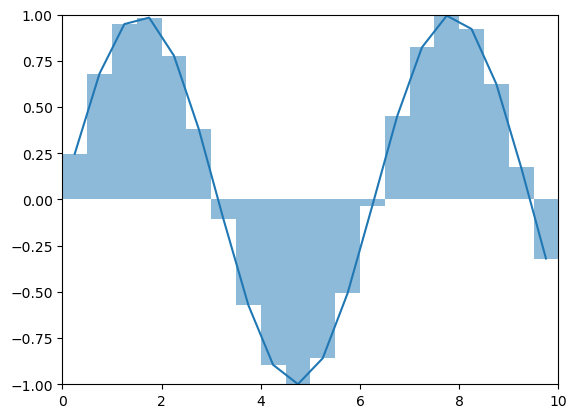

In [15]:
integral(0, 10, 20, lambda x: np.sin(x))
None

보시다시피 우리가 원하는대로, 리만 직사각형들이 모두 잘 플롯되는걸 확인할 수 있습니다.

직접 코드에서 n을 변경하신다면 n이 커질수록 모양이 더 함수가 그리는 영역에 가까워질거에요.

이제 이걸 인터랙티브 플롯해보죠. 여기는 위에서는 아직 다루지 않았던 하나의 간단한 개념이 등장합니다 :

In [16]:
# integral 함수는 파라미터가 a,b,n,f로 4개죠? 근데 우리가 바꾸고 싶은건 n 밖에 없습니다.
# 이 때는 a,b,f는 변하는 친구가 아니라 고정임을 알려주는 메소드 widgets.fixed()를 사용하시면 됩니다 :

interact(integral, a=widgets.fixed(0), b=widgets.fixed(10), n=(1, 100, 1), f=widgets.fixed(lambda x: np.sin(x)))
None

interactive(children=(IntSlider(value=50, description='n', min=1), Output()), _dom_classes=('widget-interact',…

## 예시 : 이분법과 사이값 정리

$f$가 $[a,b]$에서 연속이고, $f(a)f(b)<0$이라면, $f(c) = 0$인 $c\in(a,b)$가 존재합니다.

직관적으로는 $f$가 연속적이라 끊김이 없는데, $(a,b)$에서 한 번은 부호가 바뀌었을테니, 그 사이엔 영점이 하나는 있어야한다는거죠.

이 정리를 사이값 정리(영점 정리)라 하며, 이분법은 이 아이디어를 적극 활용합니다.

이분법이 실제로 잘 작동하는지를 증명하는 방법은 여럿 알려져있는데요, 그 중에는 알고리즘으로 사용할 수 있는 증명도 있습니다.

간단히 증명의 스케치만 설명하자면 우선 우리는 $[a,b]$의 부분 구간에서 다음을 만족하는 부분 구간들의 열 $\big([a_n, b_n]\big)_{n\in\mathbb{N}}$을 정의합니다.

$$\begin{array}{ll}
1. & f(a_n)f(b_n)<0\\
2. & b_n - a_n = \frac{b-a}{2^n}
\end{array}$$

이러한 열 $\big([a_n, b_n]\big)_{n\in\mathbb{N}}$은 $f(a)f(b)<0$이고 $f$가 연속이라면 항상 존재합니다.

그러면 사이값 정리에 의해 항상 $f(c_n) = 0$인 $c_n \in (a_n,b_n)$이 항상 존재하게 됩니다.

이 떄, 이를 만족하는 $c_n$들을 각 $n$에 대해 모아서 $(c_n)_{n\in\mathbb{N}}$를 정의하면, 이 친구는 코시 수열이 되는데요,

따라서 \[해석학 1\]의 코시 수열에 관한 성질에 의해 $c_n\underset{n\to\infty}{\to}c$인 $c\in\mathbb{R}$가 존재하며, 연속성 의해서 우리는 결국 다음을 주장할 수 있습니다.
$$
 f(c)=  f\left(\lim_{n\to\infty}c_n\right) = \lim_{n\to\infty}f(c_n) =\lim_{n\to\infty}0 = 0
$$

즉, 우리의 이분법은 이러한 $c$를 근사해내가는 형태의 반복법인거죠.

근데 이거도 결국에는 수렴이라는 아이디어로 근사해나가는 과정이다보니, 오차가 항상 발생합니다.

기존의 플롯에서는 이 오차를 고정된 값으로 정해뒀었는데요, 인터랙티브 플롯을 활용하면 이 오차를 바꿔가면서, 수렴 과정을 할 수 있습니다

In [17]:
# 전형적인 이분법 코드인데요, 이번엔 플롯을 할거니, 그걸 위한 코드들이 중간 중간 있습니다.
def bisect(f, a, b, tol):
    
    # 일단 더 좋은 가독성을 위해 원래 함수도 플롯했습니다.
    x = np.linspace(a,b,10)
    plt.plot(x,f(x))
    
    while b - a > tol:
        plt.scatter([a, b], [f(a), f(b)], color='red') # 각 단계에서의 근사점(양 끝점에서의 함수 그래프 위에서의 점)을 플롯
        m = (a + b) / 2
        if f(a) * f(m) < 0:
            b = m
        else:
            a = m
    m = (a + b) / 2
    plt.scatter(m, f(m), color='black') # tol보다 오차가 적은 경우, 즉 우리가 계산한 최종 결과물을 검정색 점으로 플롯
    return m

f = lambda x: x**2 - 2
interact(bisect, f=widgets.fixed(f), a=widgets.fixed(0), b=widgets.fixed(2), tol=widgets.FloatSlider(min=1e-5, max=1, step=1e-5, value=1e-5))
None

interactive(children=(FloatSlider(value=1e-05, description='tol', max=1.0, min=1e-05, step=1e-05), Output()), …

간단합니다. 여기서 우리가 예상할 수 있는건 넘겨주는 함수가 $x^2 - 2$이니, 이분법은 $\sqrt{2}$의 근처로 향하는 점들을 찍게 됩니다.

또한 이분법은 구간을 자꾸 나누는데, `tol`은 이 구간을 얼마나 작게 나눌건지를 지정하는 동시에, 근사의 정확도를 결정하므로,

크면 클수록 근사는 정확하지 않고, 작으면 작을수록 근사가 정확해집니다.

그걸 위의 `tol`을 움직이시면서 직관적으로 확인 가능하실거에요.